<a href="https://colab.research.google.com/github/SANGHATI23/sam-brats-robustness-audit/blob/main/06_MedReasoner_Visual_Evidence_Ablation_Qwen25VL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CELL 1 — Runtime check
import sys, platform, torch
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if not torch.cuda.is_available():
    raise RuntimeError("GPU runtime required.")
print("GPU:", torch.cuda.get_device_name(0))
props = torch.cuda.get_device_properties(0)
print(f"GPU memory: {props.total_memory / 1024**3:.1f} GB")

Python: 3.12.13
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB
GPU memory: 79.3 GB


In [2]:
# CELL 2 — Qwen dependencies only
# Do not upgrade NumPy/Pandas/SciPy/scikit-learn in Colab.
import subprocess, sys
packages = [
    "transformers>=4.49.0,<5",
    "accelerate>=1.2.0",
    "qwen-vl-utils>=0.0.10",
]
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--upgrade", *packages], check=True)
print("Qwen dependencies installed.")

Qwen dependencies installed.


In [3]:
# CELL 3 — Imports and configuration
import os, re, json, time, random, gc
from pathlib import Path
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import cv2
from tqdm.auto import tqdm
from IPython.display import display
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import (
    balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss, confusion_matrix
)
from scipy.stats import spearmanr
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info

SEED = 2026
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
MODEL_ID = "Qwen/Qwen2.5-VL-7B-Instruct"
EXPERIMENT_ID = "06_visual_evidence_ablation_qwen25vl7b"
PROMPT_VERSION = "evidence_ablation_v1.0"
OVERWRITE_EXISTING = False
MIN_PIXELS = 256 * 28 * 28
MAX_PIXELS = 1024 * 28 * 28
MAX_NEW_TOKENS = 150
DOMAIN_TARGET = {
    "brain_mri": {"domain_text":"brain MRI", "target_text":"brain tumor"},
    "kidney_ct": {"domain_text":"kidney CT", "target_text":"kidney tumor"},
    "histopathology": {"domain_text":"H&E histopathology", "target_text":"cell nuclei"},
}
print("Experiment:", EXPERIMENT_ID)
print("Model:", MODEL_ID)

Experiment: 06_visual_evidence_ablation_qwen25vl7b
Model: Qwen/Qwen2.5-VL-7B-Instruct


In [4]:
# CELL 4 — Mount Drive and load Notebook-04 controlled benchmark
from google.colab import drive
DRIVE = Path("/content/drive")
if not (DRIVE / "MyDrive").exists():
    drive.mount(str(DRIVE), force_remount=False)
ROOT = DRIVE / "MyDrive" / "MedReasoner_SAM_2026"
CF_ROOT = ROOT / "04_counterfactual_masks"
OUTPUT_DIR = ROOT / "03_vlm_outputs"
EVAL_DIR = ROOT / "05_evaluation"
FIG_DIR = ROOT / "06_figures"
ABLATION_ASSET_DIR = CF_ROOT / "evidence_ablation"
LOG_DIR = ROOT / "logs"
for p in [OUTPUT_DIR, EVAL_DIR, FIG_DIR, ABLATION_ASSET_DIR, LOG_DIR]:
    p.mkdir(parents=True, exist_ok=True)
CF_PATH = CF_ROOT / "counterfactual_hidden_labels.csv"
QWEN_FULL_PATH = EVAL_DIR / "04_counterfactual_qc_qwen25vl7b_case_level_evaluation.csv"
if not CF_PATH.exists(): raise FileNotFoundError(CF_PATH)
if not QWEN_FULL_PATH.exists(): raise FileNotFoundError(QWEN_FULL_PATH)
cf = pd.read_csv(CF_PATH)
full_qwen = pd.read_csv(QWEN_FULL_PATH)
if len(cf) != 270: raise ValueError(f"Expected 270 counterfactual cases, found {len(cf)}.")
required = {"cf_id","base_id","domain","condition","is_corrupted","reference_dice","dice_degradation","image_path","candidate_mask_path","vlm_overlay_path"}
missing = sorted(required - set(cf.columns))
if missing: raise ValueError(f"Counterfactual file missing columns: {missing}")
if cf["is_corrupted"].dtype == object:
    cf["is_corrupted"] = cf["is_corrupted"].astype(str).str.lower().map({"true":True,"false":False})
print("Counterfactual cases:", len(cf))
print("Base cases:", cf["base_id"].nunique())
display(cf.groupby(["domain","condition"]).size().reset_index(name="n"))

Mounted at /content/drive
Counterfactual cases: 270
Base cases: 45


,domain,condition,n
0,brain_mri,CLEAN,15
1,brain_mri,OVERSEGMENTATION,15
2,brain_mri,PARTIAL_MISSING,15
3,brain_mri,SHIFT,15
4,brain_mri,UNDERSEGMENTATION,15
5,brain_mri,WRONG_REGION,15
6,histopathology,CLEAN,15
7,histopathology,OVERSEGMENTATION,15
8,histopathology,PARTIAL_MISSING,15
9,histopathology,SHIFT,15


In [5]:
# CELL 5 — Build MASK_ONLY images and unique IMAGE_ONLY table
def read_mask(path):
    m = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if m is None: raise FileNotFoundError(path)
    return (m > 0).astype(np.uint8)

def save_rgb(path, rgb):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(path), cv2.cvtColor(rgb.astype(np.uint8), cv2.COLOR_RGB2BGR))

def make_mask_only(mask):
    h, w = mask.shape
    canvas = np.zeros((h,w,3), dtype=np.uint8)
    canvas[mask > 0] = np.array([255,0,0], dtype=np.uint8)
    contours, _ = cv2.findContours(((mask>0).astype(np.uint8)*255), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(canvas, contours, -1, (255,0,0), 2)
    return canvas

mask_rows=[]
for _, r in tqdm(cf.iterrows(), total=len(cf), desc="Building mask-only views"):
    mask = read_mask(r["candidate_mask_path"])
    out_dir = ABLATION_ASSET_DIR / "mask_only"; out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"{r['cf_id']}_mask_only.png"
    if not out_path.exists(): save_rgb(out_path, make_mask_only(mask))
    mask_rows.append({
        "ablation_id":f"MASK_{r['cf_id']}", "cf_id":r["cf_id"], "base_id":r["base_id"],
        "domain":r["domain"], "view":"MASK_ONLY", "image_input_path":str(out_path)
    })
mask_manifest = pd.DataFrame(mask_rows)
image_unique = cf.sort_values(["base_id","condition"]).drop_duplicates("base_id", keep="first")[["base_id","domain","image_path"]].copy()
image_unique["ablation_id"] = "IMAGE_" + image_unique["base_id"].astype(str)
image_unique["view"] = "IMAGE_ONLY"
image_unique = image_unique.rename(columns={"image_path":"image_input_path"})
print("Mask-only inference images:", len(mask_manifest))
print("Unique image-only inference images:", len(image_unique))

Building mask-only views:   0%|          | 0/270 [00:00<?, ?it/s]

Mask-only inference images: 270
Unique image-only inference images: 45


In [6]:
# CELL 6 — Evidence-ablation prompts
def build_prompt(view, domain_text, target_text):
    if view == "MASK_ONLY":
        evidence_text = """Evidence view: MASK ONLY.\nThe original medical image is hidden.\nThe RED shape is the candidate segmentation mask on a blank background.\nJudge whether mask morphology, size, position, fragmentation, or other visible mask-only cues suggest that the associated candidate segmentation is corrupted."""
    elif view == "IMAGE_ONLY":
        evidence_text = """Evidence view: IMAGE ONLY.\nThe candidate segmentation mask is hidden.\nThis is a negative-control ablation. Based only on the medical image and task context, estimate whether the associated candidate segmentation is corrupted."""
    else:
        raise ValueError(view)
    return f"""
You are participating in a controlled evidence-ablation experiment for medical-image segmentation quality control.

Image domain: {domain_text}
Intended segmentation target: {target_text}

{evidence_text}

Return ONLY one valid JSON object:
{{
  "qc_label": "CLEAN|CORRUPTED",
  "corruption_probability": 0,
  "grounding": "one concise sentence describing what visible evidence drove the decision"
}}

Rules:
- corruption_probability must be an integer from 0 to 100.
- Do not give a diagnosis.
- Do not discuss Dice, IoU, ground truth, or hidden information.
- grounding must be no more than 35 words.
- Output JSON only; no markdown.
""".strip()

print(build_prompt("MASK_ONLY", "kidney CT", "kidney tumor"))

You are participating in a controlled evidence-ablation experiment for medical-image segmentation quality control.

Image domain: kidney CT
Intended segmentation target: kidney tumor

Evidence view: MASK ONLY.
The original medical image is hidden.
The RED shape is the candidate segmentation mask on a blank background.
Judge whether mask morphology, size, position, fragmentation, or other visible mask-only cues suggest that the associated candidate segmentation is corrupted.

Return ONLY one valid JSON object:
{
  "qc_label": "CLEAN|CORRUPTED",
  "corruption_probability": 0,
  "grounding": "one concise sentence describing what visible evidence drove the decision"
}

Rules:
- corruption_probability must be an integer from 0 to 100.
- Do not give a diagnosis.
- Do not discuss Dice, IoU, ground truth, or hidden information.
- grounding must be no more than 35 words.
- Output JSON only; no markdown.


In [7]:
# CELL 7 — Prepare blinded inference manifests
def add_domain_text(df):
    out=df.copy()
    out["domain_text"] = out["domain"].map(lambda x: DOMAIN_TARGET[x]["domain_text"])
    out["target_text"] = out["domain"].map(lambda x: DOMAIN_TARGET[x]["target_text"])
    return out
mask_blind = add_domain_text(mask_manifest).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
image_blind = add_domain_text(image_unique).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
MASK_BLIND_PATH = OUTPUT_DIR / f"{EXPERIMENT_ID}_mask_only_blinded_manifest.csv"
IMAGE_BLIND_PATH = OUTPUT_DIR / f"{EXPERIMENT_ID}_image_only_blinded_manifest.csv"
mask_blind.to_csv(MASK_BLIND_PATH, index=False); image_blind.to_csv(IMAGE_BLIND_PATH, index=False)
print("MASK_ONLY rows:", len(mask_blind)); print("IMAGE_ONLY unique rows:", len(image_blind))

MASK_ONLY rows: 270
IMAGE_ONLY unique rows: 45


In [8]:
# CELL 8 — Load Qwen2.5-VL-7B-Instruct
print("Loading:", MODEL_ID)
t0=time.time()
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(MODEL_ID, torch_dtype=torch.bfloat16, device_map="auto")
processor = AutoProcessor.from_pretrained(MODEL_ID, min_pixels=MIN_PIXELS, max_pixels=MAX_PIXELS)
model.eval()
print(f"Loaded in {(time.time()-t0)/60:.1f} minutes")
print("Model commit:", getattr(model.config, "_commit_hash", None))

`torch_dtype` is deprecated! Use `dtype` instead!


Loading: Qwen/Qwen2.5-VL-7B-Instruct


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

Loaded in 0.9 minutes
Model commit: cc594898137f460bfe9f0759e9844b3ce807cfb5


In [9]:
# CELL 9 — Parser
ALLOWED={"CLEAN","CORRUPTED"}
def extract_json(text):
    text=str(text).strip(); text=re.sub(r"^```(?:json)?\s*","",text,flags=re.I); text=re.sub(r"\s*```$","",text)
    try:
        obj=json.loads(text)
        if isinstance(obj,dict): return obj
    except: pass
    m=re.search(r"\{.*\}",text,flags=re.S)
    if m:
        try:
            obj=json.loads(m.group(0))
            if isinstance(obj,dict): return obj
        except: pass
    return None

def normalize(raw):
    obj=extract_json(raw)
    out={"parse_ok":False,"qc_label":None,"corruption_probability":np.nan,"grounding":None}
    if obj is None: return out
    label=str(obj.get("qc_label","")).strip().upper(); grounding=str(obj.get("grounding","")).strip()
    try: prob=int(round(float(obj.get("corruption_probability"))))
    except: prob=None
    if label not in ALLOWED or prob is None or not (0<=prob<=100) or not grounding: return out
    out.update({"parse_ok":True,"qc_label":label,"corruption_probability":prob,"grounding":grounding})
    return out

In [10]:
# CELL 10 — Single-case inference
def run_case(row):
    image_uri = Path(str(row["image_input_path"])).resolve().as_uri()
    prompt = build_prompt(str(row["view"]), str(row["domain_text"]), str(row["target_text"]))
    messages=[{"role":"user","content":[{"type":"image","image":image_uri},{"type":"text","text":prompt}]}]
    chat_text=processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs,video_inputs=process_vision_info(messages)
    inputs=processor(text=[chat_text],images=image_inputs,videos=video_inputs,padding=True,return_tensors="pt").to(model.device)
    t0=time.time()
    with torch.inference_mode():
        ids=model.generate(**inputs,max_new_tokens=MAX_NEW_TOKENS,do_sample=False,use_cache=True)
    ids=ids[:,inputs.input_ids.shape[1]:]
    raw=processor.batch_decode(ids,skip_special_tokens=True,clean_up_tokenization_spaces=False)[0].strip()
    parsed=normalize(raw)
    result={
        "ablation_id":str(row["ablation_id"]),"view":str(row["view"]),"domain":str(row["domain"]),
        "model_id":MODEL_ID,"prompt_version":PROMPT_VERSION,"raw_output":raw,"parse_ok":bool(parsed["parse_ok"]),
        "qc_label":parsed["qc_label"],"corruption_probability":None if pd.isna(parsed["corruption_probability"]) else int(parsed["corruption_probability"]),
        "grounding":parsed["grounding"],"generation_seconds":float(time.time()-t0),"timestamp_utc":datetime.now(timezone.utc).isoformat()
    }
    if "cf_id" in row.index: result["cf_id"]=str(row["cf_id"])
    if "base_id" in row.index: result["base_id"]=str(row["base_id"])
    del inputs,ids,image_inputs,video_inputs
    return result

In [11]:
# CELL 11 — Smoke tests
mask_smoke=run_case(mask_blind.iloc[0]); image_smoke=run_case(image_blind.iloc[0])
print("MASK_ONLY"); print(json.dumps(mask_smoke,indent=2)); print("\nIMAGE_ONLY"); print(json.dumps(image_smoke,indent=2))
if not mask_smoke["parse_ok"]: raise RuntimeError("MASK_ONLY smoke test failed.")
if not image_smoke["parse_ok"]: raise RuntimeError("IMAGE_ONLY smoke test failed.")

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


MASK_ONLY
{
  "ablation_id": "MASK_CF_0075",
  "view": "MASK_ONLY",
  "domain": "brain_mri",
  "model_id": "Qwen/Qwen2.5-VL-7B-Instruct",
  "prompt_version": "evidence_ablation_v1.0",
  "raw_output": "```json\n{\n  \"qc_label\": \"CORRUPTED\",\n  \"corruption_probability\": 70,\n  \"grounding\": \"The mask appears fragmented and lacks clear anatomical boundaries, suggesting potential corruption.\"\n}\n```",
  "parse_ok": true,
  "qc_label": "CORRUPTED",
  "corruption_probability": 70,
  "grounding": "The mask appears fragmented and lacks clear anatomical boundaries, suggesting potential corruption.",
  "generation_seconds": 4.42091703414917,
  "timestamp_utc": "2026-08-08T05:08:13.098274+00:00",
  "cf_id": "CF_0075",
  "base_id": "BASE_013"
}

IMAGE_ONLY
{
  "ablation_id": "IMAGE_BASE_011",
  "view": "IMAGE_ONLY",
  "domain": "brain_mri",
  "model_id": "Qwen/Qwen2.5-VL-7B-Instruct",
  "prompt_version": "evidence_ablation_v1.0",
  "raw_output": "{\n  \"qc_label\": \"CORRUPTED\",\n  \"co

In [12]:
# CELL 12 — Run/resume helper
def completed_ids(path):
    done=set()
    if not Path(path).exists(): return done
    with open(path,"r",encoding="utf-8") as f:
        for line in f:
            try: done.add(str(json.loads(line)["ablation_id"]))
            except: pass
    return done

def run_manifest(manifest,jsonl_path,description):
    if OVERWRITE_EXISTING and Path(jsonl_path).exists(): Path(jsonl_path).unlink()
    done=completed_ids(jsonl_path); errors=[]
    print(description,"previously completed:",len(done))
    for i,(_,row) in enumerate(tqdm(manifest.iterrows(),total=len(manifest),desc=description),start=1):
        aid=str(row["ablation_id"])
        if aid in done: continue
        try:
            result=run_case(row)
            with open(jsonl_path,"a",encoding="utf-8") as f:
                f.write(json.dumps(result,ensure_ascii=False)+"\n"); f.flush()
            done.add(aid)
        except Exception as e:
            errors.append({"ablation_id":aid,"view":row["view"],"error":repr(e)})
        if i%20==0: gc.collect(); torch.cuda.empty_cache()
    print(description,"completed:",len(done)); print(description,"runtime errors:",len(errors))
    if errors: display(pd.DataFrame(errors))
    return errors

In [13]:
# CELL 13 — Run MASK_ONLY and IMAGE_ONLY ablations
MASK_JSONL=OUTPUT_DIR/f"{EXPERIMENT_ID}_mask_only_predictions.jsonl"
IMAGE_JSONL=OUTPUT_DIR/f"{EXPERIMENT_ID}_image_only_predictions.jsonl"
mask_errors=run_manifest(mask_blind,MASK_JSONL,"MASK_ONLY")
image_errors=run_manifest(image_blind,IMAGE_JSONL,"IMAGE_ONLY")

MASK_ONLY previously completed: 0


MASK_ONLY:   0%|          | 0/270 [00:00<?, ?it/s]

MASK_ONLY completed: 270
MASK_ONLY runtime errors: 0
IMAGE_ONLY previously completed: 0


IMAGE_ONLY:   0%|          | 0/45 [00:00<?, ?it/s]

IMAGE_ONLY completed: 45
IMAGE_ONLY runtime errors: 0


In [14]:
# CELL 14 — Load ablation predictions
def load_jsonl(path):
    rows=[]
    with open(path,"r",encoding="utf-8") as f:
        for line in f:
            if line.strip(): rows.append(json.loads(line))
    out=pd.DataFrame(rows)
    return out.sort_values("timestamp_utc").drop_duplicates("ablation_id",keep="last").reset_index(drop=True)
mask_pred=load_jsonl(MASK_JSONL); image_pred_unique=load_jsonl(IMAGE_JSONL)
print("MASK_ONLY predictions:",len(mask_pred),"/",len(mask_blind))
print("MASK_ONLY parse success:",f"{mask_pred['parse_ok'].mean()*100:.1f}%")
print("IMAGE_ONLY unique predictions:",len(image_pred_unique),"/",len(image_blind))
print("IMAGE_ONLY parse success:",f"{image_pred_unique['parse_ok'].mean()*100:.1f}%")
display(mask_pred["qc_label"].value_counts(dropna=False).rename_axis("qc_label").reset_index(name="n"))
display(image_pred_unique["qc_label"].value_counts(dropna=False).rename_axis("qc_label").reset_index(name="n"))

MASK_ONLY predictions: 270 / 270
MASK_ONLY parse success: 100.0%
IMAGE_ONLY unique predictions: 45 / 45
IMAGE_ONLY parse success: 100.0%


,qc_label,n
0,CORRUPTED,270


,qc_label,n
0,CORRUPTED,24
1,CLEAN,21


In [15]:
# CELL 15 — Expand IMAGE_ONLY predictions; assemble three views
image_expand=cf[["cf_id","base_id","domain","condition","is_corrupted","reference_dice","dice_degradation"]].copy()
image_expand=image_expand.merge(image_pred_unique[["base_id","parse_ok","qc_label","corruption_probability","grounding","generation_seconds"]],on="base_id",how="left",validate="many_to_one")
image_expand["view"]="IMAGE_ONLY"
mask_eval=mask_pred.merge(cf[["cf_id","base_id","domain","condition","is_corrupted","reference_dice","dice_degradation"]],on=["cf_id","base_id","domain"],how="inner",validate="one_to_one")
mask_eval["view"]="MASK_ONLY"
full=full_qwen.copy()
for c in ["is_corrupted","pred_corrupted"]:
    if c in full.columns and full[c].dtype==object:
        full[c]=full[c].astype(str).str.lower().map({"true":True,"false":False})
full_eval=full[["cf_id","base_id","domain","condition","is_corrupted","reference_dice","dice_degradation","parse_ok","qc_label","corruption_probability","grounding"]].copy()
full_eval["view"]="FULL_OVERLAY"
print("FULL_OVERLAY rows:",len(full_eval)); print("MASK_ONLY rows:",len(mask_eval)); print("IMAGE_ONLY expanded rows:",len(image_expand))

FULL_OVERLAY rows: 270
MASK_ONLY rows: 270
IMAGE_ONLY expanded rows: 270


In [16]:
# CELL 16 — Common metrics
def prepare_view(df):
    x=df[df["parse_ok"]==True].copy()
    x["pred_corrupted"]=x["qc_label"]=="CORRUPTED"
    x["corruption_score"]=pd.to_numeric(x["corruption_probability"],errors="coerce")/100.0
    return x

def binary_metrics(df):
    y=df["is_corrupted"].astype(int).to_numpy(); p=df["pred_corrupted"].astype(int).to_numpy(); s=df["corruption_score"].astype(float).to_numpy()
    tn,fp,fn,tp=confusion_matrix(y,p,labels=[0,1]).ravel()
    out={
        "n":int(len(df)),"balanced_accuracy":float(balanced_accuracy_score(y,p)),
        "sensitivity":float(recall_score(y,p,zero_division=0)),"specificity":float(tn/(tn+fp)) if tn+fp else np.nan,
        "precision":float(precision_score(y,p,zero_division=0)),"f1":float(f1_score(y,p,zero_division=0)),
        "false_reassurance_rate":float(fn/(fn+tp)) if fn+tp else np.nan,"false_alarm_rate":float(fp/(fp+tn)) if fp+tn else np.nan
    }
    if len(np.unique(y))==2 and np.isfinite(s).all():
        out.update({"auroc":float(roc_auc_score(y,s)),"auprc":float(average_precision_score(y,s)),"brier":float(brier_score_loss(y,s))})
    else:
        out.update({"auroc":np.nan,"auprc":np.nan,"brier":np.nan})
    return out

full_valid=prepare_view(full_eval); mask_valid=prepare_view(mask_eval); image_valid=prepare_view(image_expand)
view_dfs={"FULL_OVERLAY":full_valid,"MASK_ONLY":mask_valid,"IMAGE_ONLY":image_valid}
metric_rows=[]
for view,ddf in view_dfs.items():
    row=binary_metrics(ddf); row["view"]=view
    source={"FULL_OVERLAY":full_eval,"MASK_ONLY":mask_eval,"IMAGE_ONLY":image_expand}[view]
    row["parse_success_rate"]=float(source["parse_ok"].mean()); metric_rows.append(row)
view_metrics=pd.DataFrame(metric_rows)
VIEW_METRICS_PATH=EVAL_DIR/f"{EXPERIMENT_ID}_view_metrics.csv"; view_metrics.to_csv(VIEW_METRICS_PATH,index=False)
display(view_metrics)

,n,balanced_accuracy,sensitivity,specificity,precision,f1,false_reassurance_rate,false_alarm_rate,auroc,auprc,brier,view,parse_success_rate
0,270,0.604444,0.897778,0.311111,0.866953,0.882096,0.102222,0.688889,0.604444,0.863516,0.208778,FULL_OVERLAY,1.0
1,270,0.500000,1.000000,0.000000,0.833333,0.909091,0.000000,1.000000,0.552049,0.857858,0.143472,MASK_ONLY,1.0
2,270,0.500000,0.533333,0.466667,0.833333,0.650407,0.466667,0.533333,0.500000,0.833333,0.466667,IMAGE_ONLY,1.0


In [17]:
# CELL 17 — Complete paired case table
def compact(df,prefix):
    return df[["cf_id","base_id","domain","condition","is_corrupted","reference_dice","dice_degradation","qc_label","corruption_score"]].rename(columns={"qc_label":f"{prefix}_label","corruption_score":f"{prefix}_score"})
paired=compact(full_valid,"full").merge(compact(mask_valid,"mask")[["cf_id","mask_label","mask_score"]],on="cf_id",how="inner",validate="one_to_one").merge(compact(image_valid,"image")[["cf_id","image_label","image_score"]],on="cf_id",how="inner",validate="one_to_one")
for prefix in ["full","mask","image"]: paired[f"{prefix}_pred"]=paired[f"{prefix}_label"]=="CORRUPTED"
PAIR_PATH=EVAL_DIR/f"{EXPERIMENT_ID}_paired_case_table.csv"; paired.to_csv(PAIR_PATH,index=False)
print("Complete paired cases:",len(paired)); display(paired.head())

Complete paired cases: 270


,cf_id,base_id,domain,condition,is_corrupted,reference_dice,dice_degradation,full_label,full_score,mask_label,mask_score,image_label,image_score,full_pred,mask_pred,image_pred
0,CF_0075,BASE_013,brain_mri,OVERSEGMENTATION,True,0.586633,4.133666e-01,CORRUPTED,0.7,CORRUPTED,0.70,CORRUPTED,0.75,True,True,True
1,CF_0132,BASE_022,kidney_ct,WRONG_REGION,True,0.000000,1.000000e+00,CORRUPTED,0.7,CORRUPTED,0.90,CORRUPTED,0.75,True,True,True
2,CF_0259,BASE_044,histopathology,CLEAN,False,1.000000,1.321165e-14,CORRUPTED,0.7,CORRUPTED,0.75,CLEAN,0.00,True,True,False
3,CF_0184,BASE_031,histopathology,UNDERSEGMENTATION,True,0.897124,1.028763e-01,CLEAN,0.0,CORRUPTED,0.70,CLEAN,0.00,False,True,False
4,CF_0197,BASE_033,histopathology,PARTIAL_MISSING,True,0.571488,4.285119e-01,CORRUPTED,0.7,CORRUPTED,0.80,CLEAN,0.00,True,True,False


In [18]:
# CELL 18 — Paired bootstrap evidence-view differences
def paired_metric(df,prefix,metric):
    y=df["is_corrupted"].astype(int)
    if metric=="balanced_accuracy": return balanced_accuracy_score(y,df[f"{prefix}_pred"].astype(int))
    if metric=="auroc":
        if len(np.unique(y))<2: return np.nan
        return roc_auc_score(y,df[f"{prefix}_score"])
    raise ValueError(metric)

def bootstrap_difference(df,a,b,metric,n_boot=5000):
    rng=np.random.default_rng(SEED); diffs=[]; n=len(df)
    for _ in range(n_boot):
        sample=df.iloc[rng.integers(0,n,size=n)]
        av=paired_metric(sample,a,metric); bv=paired_metric(sample,b,metric)
        if np.isfinite(av) and np.isfinite(bv): diffs.append(av-bv)
    diffs=np.asarray(diffs)
    return {"comparison":f"{a.upper()} minus {b.upper()}","metric":metric,"difference":float(diffs.mean()),"ci95_low":float(np.percentile(diffs,2.5)),"ci95_high":float(np.percentile(diffs,97.5)),"bootstrap_probability_difference_gt_0":float((diffs>0).mean())}

rows=[]
for metric in ["balanced_accuracy","auroc"]:
    rows += [bootstrap_difference(paired,"full","mask",metric),bootstrap_difference(paired,"full","image",metric),bootstrap_difference(paired,"mask","image",metric)]
paired_differences=pd.DataFrame(rows)
DIFF_PATH=EVAL_DIR/f"{EXPERIMENT_ID}_paired_bootstrap_differences.csv"; paired_differences.to_csv(DIFF_PATH,index=False)
display(paired_differences)

,comparison,metric,difference,ci95_low,ci95_high,bootstrap_probability_difference_gt_0
0,FULL minus MASK,balanced_accuracy,0.103802,0.035793,0.174150,0.9990
1,FULL minus IMAGE,balanced_accuracy,0.104805,0.041058,0.164328,0.9990
2,MASK minus IMAGE,balanced_accuracy,0.001003,-0.078191,0.081560,0.5042
3,FULL minus MASK,auroc,0.051479,-0.041376,0.144965,0.8634
4,FULL minus IMAGE,auroc,0.104805,0.041058,0.164328,0.9990
5,MASK minus IMAGE,auroc,0.053326,-0.062572,0.168216,0.8180


In [19]:
# CELL 19 — Within-base probability margins
margin_rows=[]
for view,ddf in view_dfs.items():
    for base_id,bdf in ddf.groupby("base_id"):
        clean=bdf[bdf["condition"]=="CLEAN"]; corrupt=bdf[bdf["condition"]!="CLEAN"]
        if len(clean)!=1 or len(corrupt)==0: continue
        clean_score=float(clean["corruption_score"].iloc[0]); corrupt_mean=float(corrupt["corruption_score"].mean())
        margin_rows.append({"view":view,"base_id":base_id,"domain":bdf["domain"].iloc[0],"clean_probability":clean_score,"mean_corrupted_probability":corrupt_mean,"corruption_margin":corrupt_mean-clean_score})
margins=pd.DataFrame(margin_rows)
MARGIN_PATH=EVAL_DIR/f"{EXPERIMENT_ID}_within_base_probability_margins.csv"; margins.to_csv(MARGIN_PATH,index=False)
margin_summary=margins.groupby("view").agg(n_bases=("base_id","size"),mean_margin=("corruption_margin","mean"),median_margin=("corruption_margin","median"),positive_margin_rate=("corruption_margin",lambda x:float((x>0).mean()))).reset_index()
display(margin_summary)

,view,n_bases,mean_margin,median_margin,positive_margin_rate
0,FULL_OVERLAY,45,0.146222,0.00,0.311111
1,IMAGE_ONLY,45,0.000000,0.00,0.000000
2,MASK_ONLY,45,0.024667,0.01,0.577778


In [20]:
# CELL 20 — Bootstrap CI for within-base margins
def bootstrap_margin_ci(values,n_boot=10000):
    values=np.asarray(values,dtype=float); rng=np.random.default_rng(SEED); n=len(values); boot=[]
    for _ in range(n_boot): boot.append(values[rng.integers(0,n,size=n)].mean())
    boot=np.asarray(boot)
    return float(values.mean()),float(np.percentile(boot,2.5)),float(np.percentile(boot,97.5))
rows=[]
for view,ddf in margins.groupby("view"):
    est,lo,hi=bootstrap_margin_ci(ddf["corruption_margin"])
    rows.append({"view":view,"mean_corruption_margin":est,"ci95_low":lo,"ci95_high":hi})
margin_ci=pd.DataFrame(rows); display(margin_ci)

,view,mean_corruption_margin,ci95_low,ci95_high
0,FULL_OVERLAY,0.146222,0.077778,0.220889
1,IMAGE_ONLY,0.000000,0.000000,0.000000
2,MASK_ONLY,0.024667,0.012444,0.036667


In [21]:
# CELL 21 — Condition-specific probability deltas vs CLEAN
condition_delta_rows=[]
for view,ddf in view_dfs.items():
    clean_scores=ddf[ddf["condition"]=="CLEAN"][["base_id","corruption_score"]].rename(columns={"corruption_score":"clean_score"})
    corrupt=ddf[ddf["condition"]!="CLEAN"].merge(clean_scores,on="base_id",how="inner",validate="many_to_one")
    corrupt["delta_vs_clean"]=corrupt["corruption_score"]-corrupt["clean_score"]
    for condition,cdf in corrupt.groupby("condition"):
        condition_delta_rows.append({"view":view,"condition":condition,"n":int(len(cdf)),"mean_delta_vs_clean":float(cdf["delta_vs_clean"].mean()),"median_delta_vs_clean":float(cdf["delta_vs_clean"].median()),"positive_delta_rate":float((cdf["delta_vs_clean"]>0).mean())})
condition_deltas=pd.DataFrame(condition_delta_rows)
COND_DELTA_PATH=EVAL_DIR/f"{EXPERIMENT_ID}_condition_probability_deltas.csv"; condition_deltas.to_csv(COND_DELTA_PATH,index=False)
display(condition_deltas.sort_values(["condition","view"]))

,view,condition,n,mean_delta_vs_clean,median_delta_vs_clean,positive_delta_rate
0,FULL_OVERLAY,OVERSEGMENTATION,45,0.171111,0.0,0.266667
10,IMAGE_ONLY,OVERSEGMENTATION,45,0.000000,0.0,0.000000
5,MASK_ONLY,OVERSEGMENTATION,45,0.018889,0.0,0.222222
1,FULL_OVERLAY,PARTIAL_MISSING,45,0.217778,0.0,0.311111
11,IMAGE_ONLY,PARTIAL_MISSING,45,0.000000,0.0,0.000000
6,MASK_ONLY,PARTIAL_MISSING,45,0.022222,0.0,0.288889
2,FULL_OVERLAY,SHIFT,45,0.093333,0.0,0.133333
12,IMAGE_ONLY,SHIFT,45,0.000000,0.0,0.000000
7,MASK_ONLY,SHIFT,45,0.005556,0.0,0.177778
3,FULL_OVERLAY,UNDERSEGMENTATION,45,0.046667,0.0,0.088889


In [22]:
# CELL 22 — Per-domain view metrics
domain_rows=[]
for view,ddf in view_dfs.items():
    for domain,x in ddf.groupby("domain"):
        m=binary_metrics(x); m["view"]=view; m["domain"]=domain; domain_rows.append(m)
domain_view_metrics=pd.DataFrame(domain_rows)
DOMAIN_VIEW_PATH=EVAL_DIR/f"{EXPERIMENT_ID}_domain_view_metrics.csv"; domain_view_metrics.to_csv(DOMAIN_VIEW_PATH,index=False)
display(domain_view_metrics[["view","domain","n","balanced_accuracy","sensitivity","specificity","auroc","auprc","false_reassurance_rate","false_alarm_rate"]])

,view,domain,n,balanced_accuracy,sensitivity,specificity,auroc,auprc,false_reassurance_rate,false_alarm_rate
0,FULL_OVERLAY,brain_mri,90,0.500000,1.000000,0.000000,0.500000,0.833333,0.000000,1.000000
1,FULL_OVERLAY,histopathology,90,0.813333,0.693333,0.933333,0.813333,0.935807,0.306667,0.066667
2,FULL_OVERLAY,kidney_ct,90,0.500000,1.000000,0.000000,0.500000,0.833333,0.000000,1.000000
3,MASK_ONLY,brain_mri,90,0.500000,1.000000,0.000000,0.660000,0.891111,0.000000,1.000000
4,MASK_ONLY,histopathology,90,0.500000,1.000000,0.000000,0.454667,0.856667,0.000000,1.000000
5,MASK_ONLY,kidney_ct,90,0.500000,1.000000,0.000000,0.556000,0.851879,0.000000,1.000000
6,IMAGE_ONLY,brain_mri,90,0.500000,1.000000,0.000000,0.500000,0.833333,0.000000,1.000000
7,IMAGE_ONLY,histopathology,90,0.500000,0.000000,1.000000,0.500000,0.833333,1.000000,0.000000
8,IMAGE_ONLY,kidney_ct,90,0.500000,0.600000,0.400000,0.500000,0.833333,0.400000,0.600000


In [23]:
# CELL 23 — Risk vs objective Dice degradation
association_rows=[]
for view,ddf in view_dfs.items():
    rho,p=spearmanr(ddf["corruption_score"],ddf["dice_degradation"],nan_policy="omit")
    association_rows.append({"view":view,"n":int(len(ddf)),"spearman_rho_probability_vs_dice_degradation":float(rho),"p_value":float(p)})
associations=pd.DataFrame(association_rows)
ASSOC_PATH=EVAL_DIR/f"{EXPERIMENT_ID}_risk_severity_association.csv"; associations.to_csv(ASSOC_PATH,index=False)
display(associations)

,view,n,spearman_rho_probability_vs_dice_degradation,p_value
0,FULL_OVERLAY,270,0.278587,0.000003
1,MASK_ONLY,270,0.123251,0.043017
2,IMAGE_ONLY,270,0.047888,0.433226


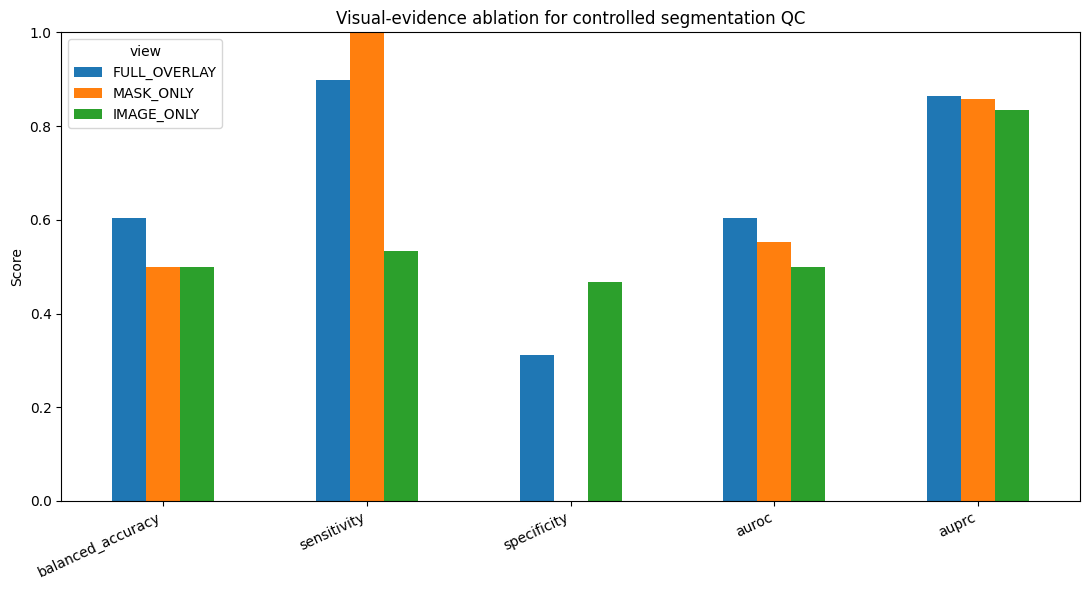

/tmp/ipykernel_6798/3005383209.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  fig,ax=plt.subplots(figsize=(8,5.5)); ax.boxplot(data,labels=ordered); ax.axhline(0,linestyle="--")


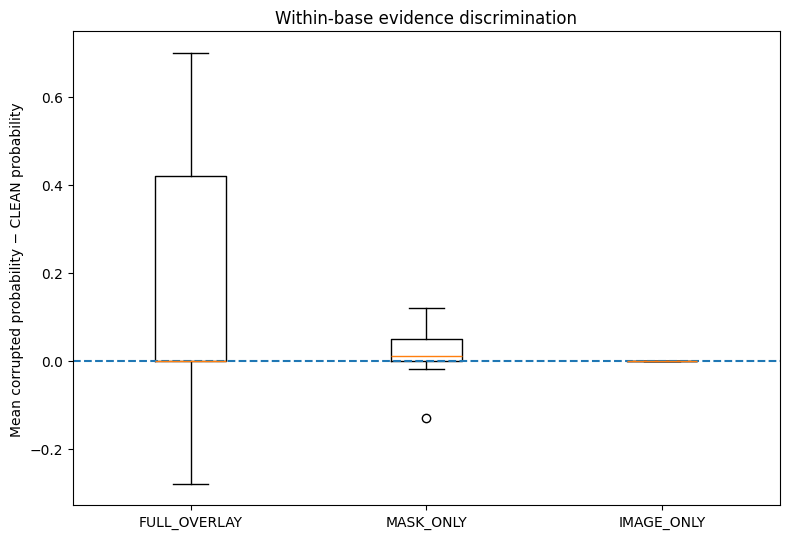

In [24]:
# CELL 24 — Main figures
metric_cols=["balanced_accuracy","sensitivity","specificity","auroc","auprc"]
ax=view_metrics[["view"]+metric_cols].set_index("view").T.plot(kind="bar",figsize=(11,6))
ax.set_ylim(0,1); ax.set_ylabel("Score"); ax.set_xlabel(""); ax.set_title("Visual-evidence ablation for controlled segmentation QC")
plt.xticks(rotation=25,ha="right"); plt.tight_layout()
METRIC_FIG=FIG_DIR/f"{EXPERIMENT_ID}_view_metric_comparison.png"; plt.savefig(METRIC_FIG,dpi=220,bbox_inches="tight"); plt.show()

ordered=["FULL_OVERLAY","MASK_ONLY","IMAGE_ONLY"]
data=[margins[margins["view"]==v]["corruption_margin"].to_numpy() for v in ordered]
fig,ax=plt.subplots(figsize=(8,5.5)); ax.boxplot(data,labels=ordered); ax.axhline(0,linestyle="--")
ax.set_ylabel("Mean corrupted probability − CLEAN probability"); ax.set_title("Within-base evidence discrimination"); plt.tight_layout()
MARGIN_FIG=FIG_DIR/f"{EXPERIMENT_ID}_within_base_margin.png"; plt.savefig(MARGIN_FIG,dpi=220,bbox_inches="tight"); plt.show()

In [25]:
# CELL 25 — Final results summary
MASK_PRED_CSV=OUTPUT_DIR/f"{EXPERIMENT_ID}_mask_only_predictions.csv"
IMAGE_PRED_CSV=OUTPUT_DIR/f"{EXPERIMENT_ID}_image_only_unique_predictions.csv"
mask_pred.to_csv(MASK_PRED_CSV,index=False); image_pred_unique.to_csv(IMAGE_PRED_CSV,index=False)
summary={
    "experiment_id":EXPERIMENT_ID,"model_id":MODEL_ID,"model_commit":getattr(model.config,"_commit_hash",None),"prompt_version":PROMPT_VERSION,
    "benchmark_cases":int(len(cf)),"base_cases":int(cf["base_id"].nunique()),
    "new_model_inferences":{"mask_only":int(len(mask_pred)),"image_only_unique":int(len(image_pred_unique))},
    "view_metrics":view_metrics.to_dict(orient="records"),
    "paired_bootstrap_differences":paired_differences.to_dict(orient="records"),
    "within_base_margin_summary":margin_summary.to_dict(orient="records"),
    "within_base_margin_ci":margin_ci.to_dict(orient="records"),
    "risk_severity_associations":associations.to_dict(orient="records")
}
SUMMARY_PATH=EVAL_DIR/f"{EXPERIMENT_ID}_summary.json"; SUMMARY_PATH.write_text(json.dumps(summary,indent=2))
print("="*92); print("VISUAL-EVIDENCE ABLATION RESULTS — QWEN2.5-VL-7B"); print("="*92)
print("View-level discrimination"); display(view_metrics[["view","n","parse_success_rate","balanced_accuracy","sensitivity","specificity","false_reassurance_rate","false_alarm_rate","auroc","auprc","brier"]])
print("Paired bootstrap evidence-view differences"); display(paired_differences)
print("Within-base corruption-probability margins"); display(margin_summary)
print("Bootstrap CIs for within-base margins"); display(margin_ci)
print("Condition-specific probability changes vs CLEAN"); display(condition_deltas.sort_values(["condition","view"]))
print("Per-domain evidence-view metrics"); display(domain_view_metrics)
print("Risk vs objective Dice degradation"); display(associations)
print("Summary saved:",SUMMARY_PATH)

VISUAL-EVIDENCE ABLATION RESULTS — QWEN2.5-VL-7B
View-level discrimination


,view,n,parse_success_rate,balanced_accuracy,sensitivity,specificity,false_reassurance_rate,false_alarm_rate,auroc,auprc,brier
0,FULL_OVERLAY,270,1.0,0.604444,0.897778,0.311111,0.102222,0.688889,0.604444,0.863516,0.208778
1,MASK_ONLY,270,1.0,0.500000,1.000000,0.000000,0.000000,1.000000,0.552049,0.857858,0.143472
2,IMAGE_ONLY,270,1.0,0.500000,0.533333,0.466667,0.466667,0.533333,0.500000,0.833333,0.466667


Paired bootstrap evidence-view differences


,comparison,metric,difference,ci95_low,ci95_high,bootstrap_probability_difference_gt_0
0,FULL minus MASK,balanced_accuracy,0.103802,0.035793,0.174150,0.9990
1,FULL minus IMAGE,balanced_accuracy,0.104805,0.041058,0.164328,0.9990
2,MASK minus IMAGE,balanced_accuracy,0.001003,-0.078191,0.081560,0.5042
3,FULL minus MASK,auroc,0.051479,-0.041376,0.144965,0.8634
4,FULL minus IMAGE,auroc,0.104805,0.041058,0.164328,0.9990
5,MASK minus IMAGE,auroc,0.053326,-0.062572,0.168216,0.8180


Within-base corruption-probability margins


...

Per-domain evidence-view metrics


,n,balanced_accuracy,sensitivity,specificity,precision,f1,false_reassurance_rate,false_alarm_rate,auroc,auprc,brier,view,domain
0,90,0.500000,1.000000,0.000000,0.833333,0.909091,0.000000,1.000000,0.500000,0.833333,0.156667,FULL_OVERLAY,brain_mri
1,90,0.813333,0.693333,0.933333,0.981132,0.812500,0.306667,0.066667,0.813333,0.935807,0.313000,FULL_OVERLAY,histopathology
2,90,0.500000,1.000000,0.000000,0.833333,0.909091,0.000000,1.000000,0.500000,0.833333,0.156667,FULL_OVERLAY,kidney_ct
3,90,0.500000,1.000000,0.000000,0.833333,0.909091,0.000000,1.000000,0.660000,0.891111,0.139750,MASK_ONLY,brain_mri
4,90,0.500000,1.000000,0.000000,0.833333,0.909091,0.000000,1.000000,0.454667,0.856667,0.150528,MASK_ONLY,histopathology
5,90,0.500000,1.000000,0.000000,0.833333,0.909091,0.000000,1.000000,0.556000,0.851879,0.140139,MASK_ONLY,kidney_ct
6,90,0.500000,1.000000,0.000000,0.833333,0.909091,0.000000,1.000000,0.500000,0.833333,0.145833,IMAGE_ONLY,brain_mri
7,90,0.500000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.500000,0.833333,0.833333,IMAGE_ONLY,histopathology
8,90,0.500000,0.600000,0.400000,0.833333,0.697674,0.400000,0.600000,0.500000,0.833333,0.420833,IMAGE_ONLY,kidney_ct


Risk vs objective Dice degradation


,view,n,spearman_rho_probability_vs_dice_degradation,p_value
0,FULL_OVERLAY,270,0.278587,0.000003
1,MASK_ONLY,270,0.123251,0.043017
2,IMAGE_ONLY,270,0.047888,0.433226


Summary saved: /content/drive/MyDrive/MedReasoner_SAM_2026/05_evaluation/06_visual_evidence_ablation_qwen25vl7b_summary.json
